# Exploratory Data Analysis (EDA)

In [105]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import OneHotEncoder,MinMaxScaler,TargetEncoder
from sklearn.impute import KNNImputer,SimpleImputer
from sklearn.model_selection import train_test_split,GridSearchCV
from sklearn.metrics import mean_squared_error, r2_score,mean_absolute_error,accuracy_score,classification_report, confusion_matrix
from sklearn.neighbors import KNeighborsClassifier

## How many rows and columns does the dataset have?

In [106]:
df = pd.read_csv("car_price.csv")
rows , cols = df.shape
print(f"rows = {rows}, columns = {cols}")

rows = 72435, columns = 10


In [107]:
df.head(20)

,model,year,price,transmission,mileage,fuelType,tax,mpg,engineSize,Make
0,A1,2017.0,12500.0,Manual,15735.0,Petrol,150.0,55.4,1.4,audi
1,A6,2016.0,16500.0,Automatic,36203.0,Diesel,20.0,64.2,2.0,audi
2,A1,2016.0,11000.0,Manual,29946.0,Petrol,30.0,55.4,1.4,audi
3,A4,2017.0,16800.0,Automatic,25952.0,Diesel,145.0,67.3,2.0,audi
4,A3,2019.0,17300.0,Manual,1998.0,Petrol,145.0,49.6,1.0,audi
5,A1,2016.0,13900.0,Automatic,32260.0,Petrol,30.0,58.9,1.4,audi
6,A6,2016.0,13250.0,Automatic,76788.0,Diesel,30.0,61.4,2.0,audi
7,A4,2016.0,11750.0,NaN,75185.0,Diesel,20.0,70.6,2.0,audi
8,A3,2015.0,10200.0,Manual,46112.0,Petrol,20.0,60.1,1.4,audi
9,A1,2016.0,12000.0,Manual,22451.0,NaN,30.0,55.4,1.4,audi


In [108]:
df.describe()

,year,price,mileage,tax,mpg,engineSize
count,68813.000000,68814.000000,68813.000000,68814.000000,68814.000000,68813.000000
mean,2017.077660,16583.919261,23179.439539,116.930421,55.836352,1.635373
std,2.099474,9304.412707,21347.569657,64.081931,17.043643,0.561734
min,1996.000000,495.000000,1.000000,0.000000,0.300000,0.000000
25%,2016.000000,10167.250000,7199.000000,30.000000,47.900000,1.200000
50%,2017.000000,14495.000000,17521.000000,145.000000,55.400000,1.600000
75%,2019.000000,20359.750000,32478.000000,145.000000,62.800000,2.000000
max,2020.000000,145000.000000,323000.000000,580.000000,470.800000,6.600000


## Which features are numerical? Which are categorical?

In [109]:
df.dtypes

model            object
year            float64
price           float64
transmission     object
mileage         float64
fuelType         object
tax             float64
mpg             float64
engineSize      float64
Make             object
dtype: object

## Are there any missing values? How many, and in which columns?

In [110]:
df.isnull().sum()

model           3621
year            3622
price           3621
transmission    3623
mileage         3622
fuelType        3622
tax             3621
mpg             3621
engineSize      3622
Make            3621
dtype: int64

## What does the distribution of car prices look like?

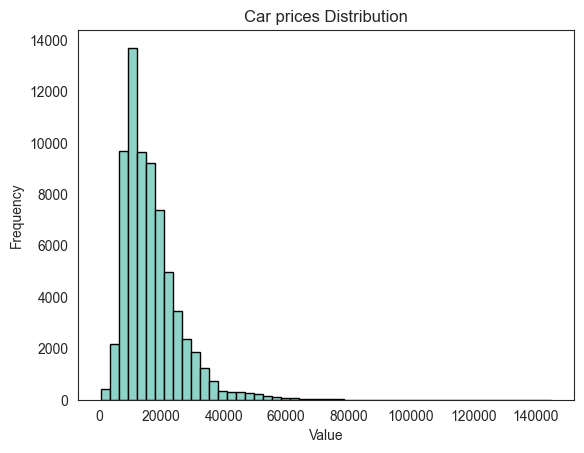

In [111]:
#shows histogram of the car prices using square root the number of rows
plt.hist(df["price"],bins=50,edgecolor='black')
plt.title('Car prices Distribution')
plt.xlabel('Value')
plt.ylabel('Frequency')
plt.show()

# Data Preprocessing

In [112]:
df = pd.read_csv('car_price.csv')

### Split the data into training and test sets 80/20 split.

In [113]:
# remove missing target values
df = df.dropna(subset=['price'])
df = df.drop_duplicates()
df['year'] = df['year'] - 2010

# splits data to 80/20
train_data, test_data = train_test_split(df, test_size=0.2, random_state=1)

#resets the index for both dataset
train_data = train_data.reset_index(drop=True)
test_data = test_data.reset_index(drop=True)

### Detect and handle outliers — use boxplots or the IQR method.


In [114]:
#taking only the numeric columns
cols = train_data.select_dtypes(include=[np.number]).columns

# Drop 'price' from the list of columns to clip
if 'price' in cols:
    cols = cols.drop('price')
#looping for each column calculating iqr to remove the outliers
for col in cols:
    q1 = train_data[col].quantile(0.25)
    q3 = train_data[col].quantile(0.75)

    iqr = q3 - q1

    upper = q3 + 1.5 * iqr
    lower = q1 - 1.5 * iqr

    outliers_count = ((train_data[col] < lower) | (train_data[col] > upper)).sum()
    print(f"{col}: {outliers_count} outliers.")

    #removes the outliers by replacing the old dataframe
    train_data[col] = train_data[col].clip(lower=lower, upper=upper)

train_data = train_data.reset_index(drop=True)

year: 931 outliers.
mileage: 2053 outliers.
tax: 189 outliers.
mpg: 805 outliers.
engineSize: 240 outliers.


### Handle missing values —drop rows, fill with mean/mode, or another strategy. Justify your choice.

- KNN Imputer will improve the accuracy by using the similar objects to predict the missing values.

In [115]:
#separating the numeric columns from the original dataset
numeric_cols = train_data.select_dtypes(include=[np.number]).columns.tolist()

if 'price' in numeric_cols:
    numeric_cols.remove('price')
#computing the missing values by the nearest 3 rows
knn = KNNImputer(n_neighbors=7)

# apply fit on the training first to avoid data leakage
train_data[numeric_cols] = knn.fit_transform(train_data[numeric_cols])
test_data[numeric_cols]  = knn.transform(test_data[numeric_cols])

# handling the missing values in the categorical columns using the mode
mode = SimpleImputer(strategy='most_frequent')

categorical_cols = [ 'model', 'Make','transmission','fuelType']
# apply fit on the training first to avoid data leakage
train_data[categorical_cols] = mode.fit_transform(train_data[categorical_cols])
test_data[categorical_cols] = mode.transform(test_data[categorical_cols])

### Encode categorical columns — use Label Encoding or One-Hot Encoding. Explain which and why.

-  One-Hot Encoding is better because in knn and liner Regression will think the higher the label the futher the traget which not true

In [116]:
# One-Hot Encode everything execpt model
ohe = OneHotEncoder(handle_unknown="ignore", sparse_output=False).set_output(transform='pandas')
encoded_train = ohe.fit_transform(train_data[categorical_cols[1:]])
encoded_test = ohe.transform(test_data[categorical_cols[1:]])
# TE will group the models and calculates the mean of each model and replaces it with the mean
te = TargetEncoder(target_type='continuous').set_output(transform='pandas')

model_train = te.fit_transform(train_data[['model']], train_data["price"])
model_test = te.transform(test_data[['model']])

# Merging the new encoded data to the DF with dropping the old categorical columns
train_data = pd.concat([train_data.drop(columns=categorical_cols), model_train, encoded_train], axis=1)
test_data = pd.concat([test_data.drop(columns=categorical_cols), model_test, encoded_test], axis=1)

### Scale numerical features — important for KNN. Use StandardScaler or MinMaxScaler.

In [117]:
#the range of the scaled values
scale = MinMaxScaler(feature_range=(0,1))

# not scaled data
train_data_raw = train_data
test_data_raw = test_data
# separating the target from the features
train_target = train_data["price"]
train_data = train_data.drop(columns=["price"])

test_target = test_data["price"]
test_data = test_data.drop(columns=["price"])
#columns names
cols = train_data.columns

#scaled data
scale_train = scale.fit_transform(train_data)
scale_test = scale.transform(test_data)

#merging the columns names with the data
train_data = pd.DataFrame(scale_train,columns=cols)
test_data = pd.DataFrame(scale_test,columns=cols)
train_data

,year,mileage,tax,mpg,engineSize,model,Make_BMW,Make_Ford,Make_Hyundai,Make_audi,...,Make_vw,transmission_Automatic,transmission_Manual,transmission_Other,transmission_Semi-Auto,fuelType_Diesel,fuelType_Electric,fuelType_Hybrid,fuelType_Other,fuelType_Petrol
0,0.882353,0.084879,0.456693,0.375000,0.468750,0.220466,0.0,1.0,0.0,0.0,...,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
1,0.764706,0.039305,0.472441,0.727349,0.312500,0.162209,0.0,0.0,0.0,0.0,...,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
2,0.647059,0.233724,0.456693,0.625000,0.312500,0.162411,0.0,1.0,0.0,0.0,...,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
3,0.647059,0.253504,0.456693,0.375000,0.625000,0.233276,0.0,0.0,0.0,1.0,...,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
4,0.882353,0.170649,0.456693,0.239094,0.625000,0.317978,0.0,0.0,0.0,1.0,...,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
54764,0.882353,0.042432,0.456693,0.482383,0.312500,0.095203,0.0,0.0,0.0,0.0,...,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
54765,0.882353,0.223056,0.456693,0.559564,0.312500,0.163575,0.0,1.0,0.0,0.0,...,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
54766,0.529412,0.307907,0.393701,0.482383,0.459821,0.162411,0.0,1.0,0.0,0.0,...,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
54767,0.647059,0.401572,0.740157,0.289430,0.937500,0.462035,0.0,1.0,0.0,0.0,...,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0


In [118]:
# assign the data to be ready for modeling
X_train = train_data
y_train = train_target.reset_index(drop=True)

X_test = test_data
y_test = test_target.reset_index(drop=True)

## Which features seem most related to price?

- the model is the most related to the price (0.76).
- year (0.54).
- mileage (-0.44).
- tax (0.36).
- mpg (-0.53).
- engine size (0.60).
- transmission_Manual (-0.50)

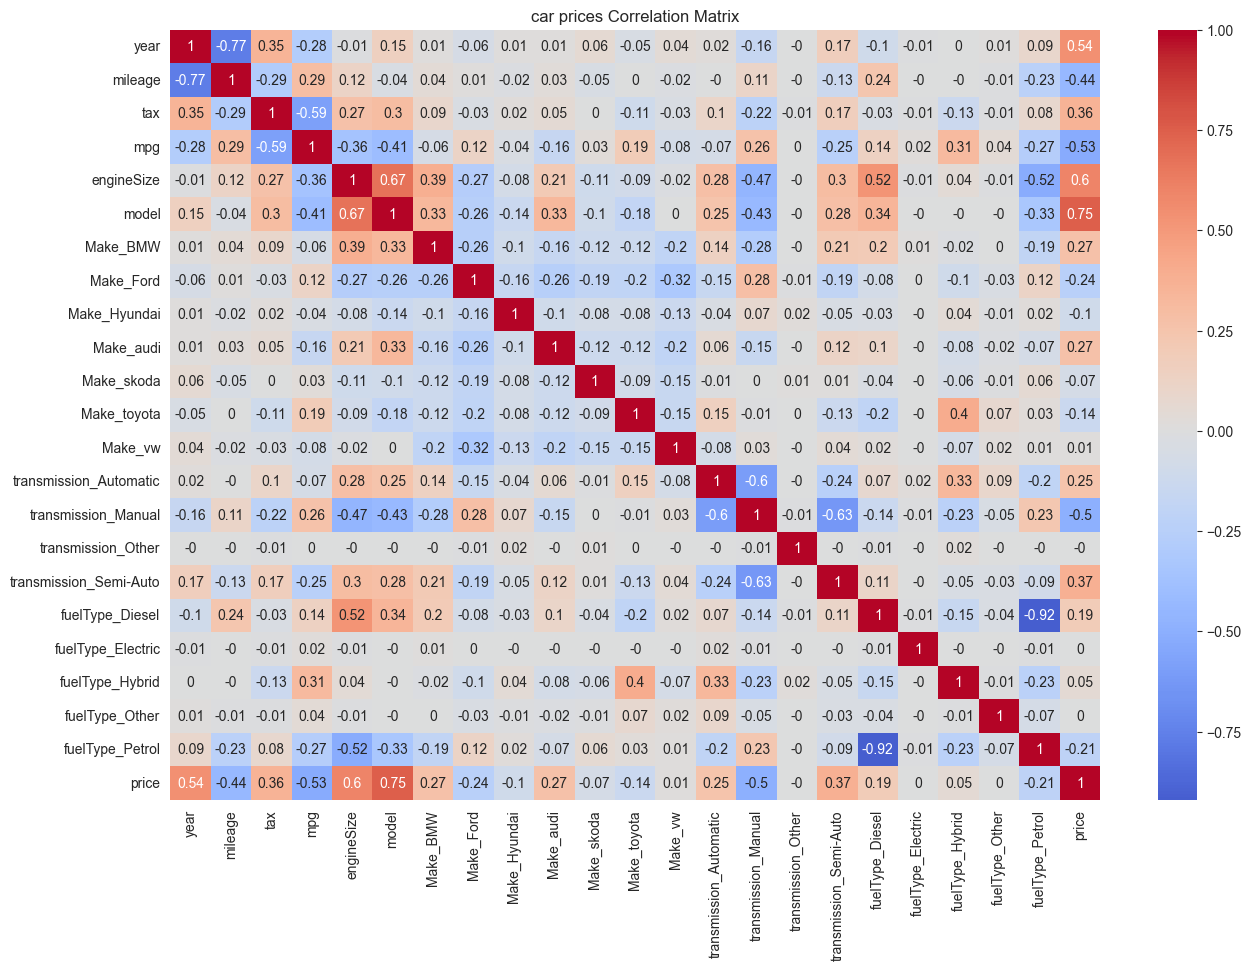

The feature with the strongest correlation to Price is: model


In [119]:
# computing the correlation rounded by 2
final_train = pd.concat([train_data,train_target], axis=1)
corr = final_train.corr().round(2)

plt.figure(figsize=(15,10))
sns.heatmap(corr, annot=True, cmap='coolwarm', center=0)
plt.title("car prices Correlation Matrix")
plt.show()

top_feature = corr['price'].drop('price').abs().idxmax()
print(f"The feature with the strongest correlation to Price is: {top_feature}")

# **Modeling and Evaluation**

# **Linear Regression**

In [120]:
# --- Simple Regression ---
simple_model = LinearRegression()
simple_model.fit(X_train[[top_feature]], y_train)
y_pred_simple = simple_model.predict(X_test[[top_feature]])

In [121]:
print(simple_model.intercept_, simple_model.coef_)

1201.0035308740098 [70357.15306426]


In [122]:
y_pred_simple

array([13177.23431154, 21923.84911153, 17561.42766029, ...,
       16004.96033068, 12620.23885328, 22701.35551607])

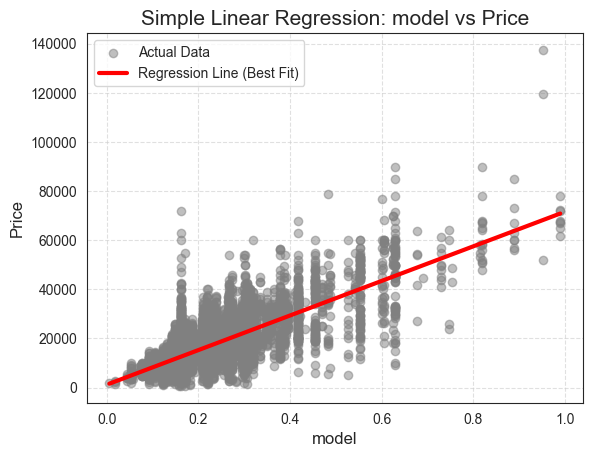

Model Equation: Price = (70357.15 * model) + 1201.00


In [123]:
feature_name = top_feature


# Plot the actual test data points
plt.scatter(X_test[[feature_name]], y_test, color='gray', alpha=0.5, label='Actual Data')

# Plot the regression line using model predictions
# We sort the values to ensure the line is drawn smoothly from left to right
X_range = np.linspace(X_test[feature_name].min(), X_test[feature_name].max(), 100).reshape(-1, 1)
y_range_pred = simple_model.predict(pd.DataFrame(X_range, columns=[feature_name]))

plt.plot(X_range, y_range_pred, color='red', linewidth=3, label='Regression Line (Best Fit)')

# Formatting
plt.title(f'Simple Linear Regression: {feature_name} vs Price', fontsize=15)
plt.xlabel(feature_name, fontsize=12)
plt.ylabel('Price', fontsize=12)
plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

# Print the model equation: Price = (Slope * Feature) + Intercept
print(f"Model Equation: Price = ({simple_model.coef_[0]:.2f} * {feature_name}) + {simple_model.intercept_:.2f}")

In [124]:
# --- Multiple Regression ---
multi_model  = LinearRegression()
multi_model .fit(X_train , y_train)
y_pred_multi = multi_model .predict(X_test)

In [125]:
print(multi_model.intercept_ ,multi_model.coef_)

3342.9103790007866 [12618.22530535 -7173.89301994 -5728.49003467 -9049.59019015
 13975.56874533 40032.2662553    501.38498386   260.61478412
  -969.9518428   1414.56388941  -482.04603718  -684.0653335
   -40.50044392   636.86807521  -518.85450793 -1448.72817119
  1330.71460391 -2449.91183307  3659.82388046  1689.89108408
  -329.93593947 -2569.867192  ]


In [126]:
y_pred_multi

array([ 6062.91372516, 25554.23521063, 20002.10812653, ...,
       10814.89400059, 10104.07059445, 20897.02486524])

In [127]:
print(f"Simple Linear Regression (Feature: {top_feature})")
print(f"R2 Score: {r2_score(y_test, y_pred_simple):.4f}")
print("-" * 30)
print("Multiple Linear Regression (All Features)")
print(f"R2 Score: {r2_score(y_test, y_pred_multi):.4f}")
print(f"Root Mean Squared Error: {np.sqrt(mean_squared_error(y_test, y_pred_multi)):.2f}")
mae = mean_absolute_error(y_test, y_pred_multi)
print("MAE:", mae)

Simple Linear Regression (Feature: model)
R2 Score: 0.5842
------------------------------
Multiple Linear Regression (All Features)
R2 Score: 0.8148
Root Mean Squared Error: 3949.87
MAE: 2469.786634354038


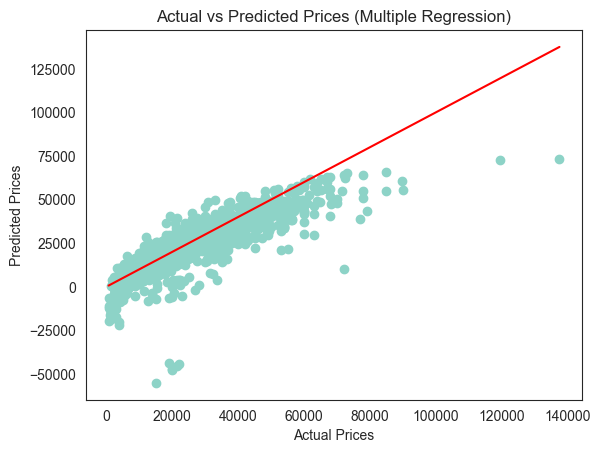

In [128]:
plt.scatter(y_test, y_pred_multi)
plt.xlabel("Actual Prices")
plt.ylabel("Predicted Prices")
plt.title("Actual vs Predicted Prices (Multiple Regression)")

# optional: perfect prediction line
plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    color='red'
)
plt.show()

## Testing on one point

In [129]:
sample = X_test.iloc[[0]]
pred = multi_model.predict(sample)

actual = y_test.iloc[0]

print("Predicted:", pred)
print("Actual:", actual)
print("Error:", abs(actual - pred))

Predicted: [6062.91372516]
Actual: 7141.0
Error: [1078.08627484]


# **KNN Classification**

**Classification Target**

In [130]:
# Price categories were created using quantile-based thresholds (33% and 66%)
# to ensure balanced classes and adaption to the data (data-driven)

# compute thresholds from TRAIN prices only to avoid data leakage
q1 = train_target.quantile(0.33)
q2 = train_target.quantile(0.66)

def price_category(price):
    if price <= q1:
        return "Cheap"
    elif price <= q2:
        return "Moderate"
    else:
        return "Expensive"

# classification targets
y_train_cls = train_target.apply(price_category)
y_test_cls = test_target.apply(price_category)

In [ ]:
print("Price Category Thresholds:")
print(f"q1: {q1:.2f}")
print(f"q2: {q2:.2f}")

Price Category Thresholds:
q1: 11485.00
q2: 17991.00


**how many cars fall into each category after splitting**

In [132]:
print("\nTraining Set Category Distribution:")
print(y_train_cls.value_counts())


Training Set Category Distribution:
price
Expensive    18621
Cheap        18079
Moderate     18069
Name: count, dtype: int64


In [133]:
print("\nTest Set Category Distribution:")
print(y_test_cls.value_counts())


Test Set Category Distribution:
price
Expensive    4617
Cheap        4608
Moderate     4468
Name: count, dtype: int64


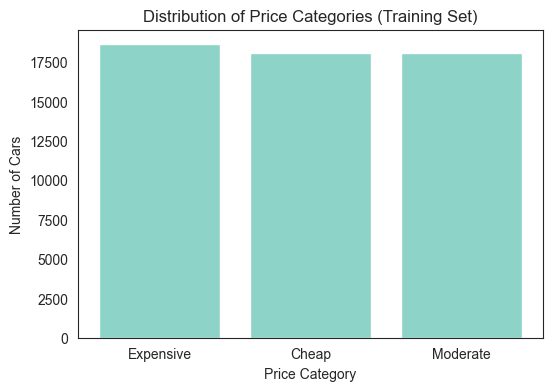

In [134]:
# Count values
counts = y_train_cls.value_counts()

plt.figure(figsize=(6,4))
plt.bar(counts.index, counts.values)

plt.xlabel("Price Category")
plt.ylabel("Number of Cars")
plt.title("Distribution of Price Categories (Training Set)")
plt.show()

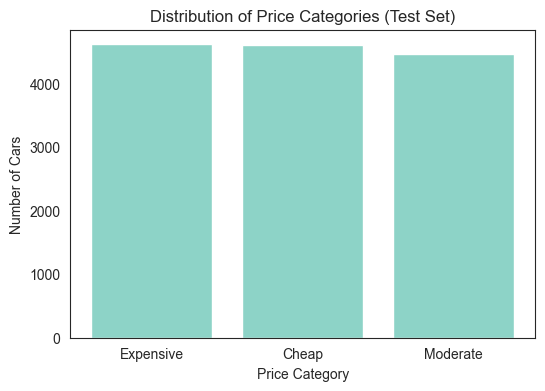

In [135]:
counts_test = y_test_cls.value_counts()

plt.figure(figsize=(6,4))
plt.bar(counts_test.index, counts_test.values)

plt.xlabel("Price Category")
plt.ylabel("Number of Cars")
plt.title("Distribution of Price Categories (Test Set)")
plt.show()

**KNN with Grid Search and kfold to find the best combination of parameters**

In [136]:
param_grid = {
    'n_neighbors': [3, 5, 7, 9, 11, 13, 15],
    'metric': ['euclidean', 'manhattan']
}

knn = KNeighborsClassifier()

grid = GridSearchCV(
    knn,
    param_grid,
    cv=5,               # 5-Fold Cross Validation
    scoring='accuracy'
)

grid.fit(train_data, y_train_cls)

GridSearchCV(cv=5, estimator=KNeighborsClassifier(),
             param_grid={'metric': ['euclidean', 'manhattan'],
                         'n_neighbors': [3, 5, 7, 9, 11, 13, 15]},
             scoring='accuracy')

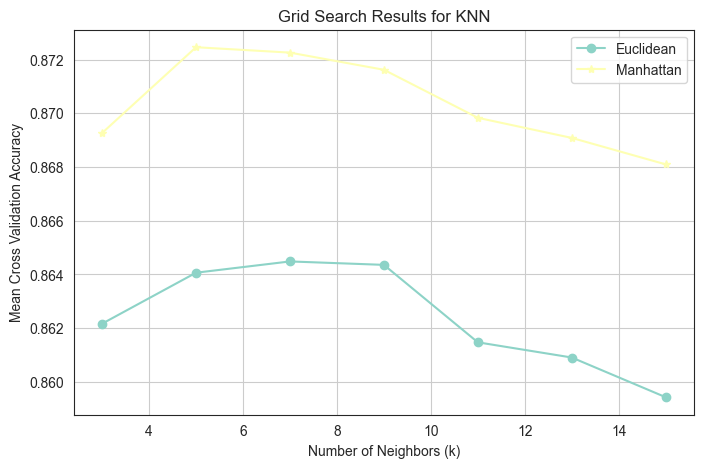

In [137]:
# Convert grid search results to DataFrame
results = pd.DataFrame(grid.cv_results_)

# Separate metrics
euclidean = results[results['param_metric'] == 'euclidean']
manhattan = results[results['param_metric'] == 'manhattan']

plt.figure(figsize=(8, 5))

plt.plot(
    euclidean['param_n_neighbors'],
    euclidean['mean_test_score'],
    marker='o',
    label='Euclidean'
)

plt.plot(
    manhattan['param_n_neighbors'],
    manhattan['mean_test_score'],
    marker='*',
    label='Manhattan'
)

plt.xlabel('Number of Neighbors (k)')
plt.ylabel('Mean Cross Validation Accuracy')
plt.title('Grid Search Results for KNN')
plt.legend()
plt.grid(True)
plt.show()

In [138]:
print("Best Parameters:", grid.best_params_)
print("Best Cross Validation Accuracy:", grid.best_score_)

Best Parameters: {'metric': 'manhattan', 'n_neighbors': 5}
Best Cross Validation Accuracy: 0.8724644434506053


**Predictions on Test Set**

In [139]:
best_knn = grid.best_estimator_
y_pred = best_knn.predict(test_data)

**Evaluation Metrics**

In [140]:
# Accuracy, Precision, Recall, F1

print(classification_report(
    y_test_cls,
    y_pred,
    target_names=["Cheap", "Moderate", "Expensive"]
))

              precision    recall  f1-score   support

       Cheap       0.91      0.90      0.91      4608
    Moderate       0.91      0.91      0.91      4617
   Expensive       0.81      0.82      0.81      4468

    accuracy                           0.88     13693
   macro avg       0.88      0.88      0.88     13693
weighted avg       0.88      0.88      0.88     13693



**Confusion Matrix**

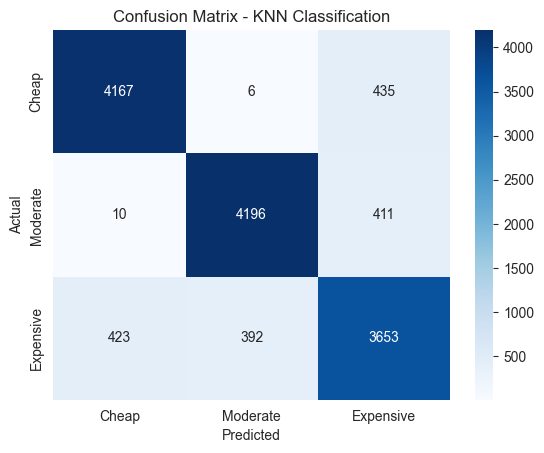

In [141]:
cm = confusion_matrix(y_test_cls, y_pred)

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    xticklabels=["Cheap", "Moderate", "Expensive"],
    yticklabels=["Cheap", "Moderate", "Expensive"],
    cmap='Blues'
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix - KNN Classification")
plt.show()

While the model is relatively good at classifying Moderate and Cheap cars, it is less effective at distinguishing the Expensive category. This suggests that the chosen price thresholds or the current feature set may not fully capture the unique characteristics of high-end vehicles

# Task 6  : Analysis and Discussion

***6.1 Model Comparison***


1.
Simple Linear Regression model achieved an R² score = 0.5842 which indicates that using a single feature is not sufficient to explain the variance in car prices and results in lower predictive performance

Multiple Linear Regression model achieved an R² score = 0.8148 (RMSE) = 4053.73 and (MAE) = 2508.59 This indicates that the model can explain about 81% of the variance in car prices with lower prediction error compared to simple regression

On the other hand, the KNN Classification model achieved an accuracy = 0.87, that mean correctly classified 87% of the cars into their respective price categories

In this context "better" depends on the objective:

For regression, better means lower error (RMSE, MAE) and higher R²
For classification better means higher accuracy and balanced performance across classes

Overall:

Multiple Linear Regression performed better than Simple Linear Regression because it uses all features and achieved higher R² with lower error
 while KNN model performed better in terms of classification accuracy
Linear Regression provides more detailed predictions  while KNN simplifies the task into categories with higher accuracy

2.
Classification is easier than regression on this dataset
 because regression requires predicting the exact car price which is a continuous value This makes the problem more complex and sensitive to small changes in the data, noise, and outliers.

classification simplifies the problem by converting the continuous price values into discrete categories (Cheap, Moderate, Expensive) This reduces the complexity of the prediction task and allows the model to focus on general patterns instead of exact values

In this dataset classification achieved relatively high accuracy (0.87) which shows that grouping prices into categories makes the learning task easier for the model
regression models showed different performance:

-Simple Linear Regression (R² = 0.5842) performed poorly because it depends on only one feature

-Multiple Linear Regression (R² = 0.8148) performed better but still requires predicting exact values

This confirms that classification is easier than regression as it reduces the prediction difficulty compared to estimating exact prices



3.

Yes converting price into categories loses important information
This is because the original price is a continuous value where small differences between prices can be meaningful (for example, 15000 and 17000) When we convert prices into categories such as Cheap, Moderate, and Expensive we group different values into the same class which removes these differences
this make models like Linear Regression (simple and multiple) can capture detailed variations in price while classification models lose this level of precision
However this simplification makes the problem easier to solve and help models like KNN achieve higher accuracy even though some detailed information is lost





**6.2  Sensitivity Analysis**

In [142]:
X_train_drop = X_train.drop(columns=[top_feature])
X_test_drop = X_test.drop(columns=[top_feature])

model = LinearRegression()
model.fit(X_train_drop, y_train)
y_pred = model.predict(X_test_drop)

print("R2 after removing feature:", r2_score(y_test, y_pred))

R2 after removing feature: 0.6940170198380871


In [143]:
knn = KNeighborsClassifier(metric='manhattan', n_neighbors=9)
knn.fit(X_train_drop, y_train_cls)
y_pred_knn = knn.predict(X_test_drop)

print("Accuracy after removing feature:", accuracy_score(y_test_cls, y_pred_knn))

Accuracy after removing feature: 0.8634338713211129




1.
   Removing the most correlated feature leads to a noticeable drop in performance for the regression model

For the Multiple Linear Regression model the R² score decreased from 0.8081 to 0.6904 after removing the most correlated feature This shows a significant reduction in performance meaning the model become less able to explain the variance in car prices without this important feature

This confirms that the model strongly depends on highly correlated features to make accurate predictions

For the KNN classification model the accuracy decreased slightly from about 0.87 to 0.859 after removing the feature This indicates that KNN is less sensitive to the removal of a single feature likely because it uses multiple features and distance-based relationships
 Conclusion

Regression model is highly sensitive to removing important features
KNN classification is more stable, with only minor changes in performance




In [144]:
X_train_raw = train_data_raw.drop(columns=["price"]).copy()
X_test_raw = test_data_raw.drop(columns=["price"]).copy()

knn = KNeighborsClassifier(metric='manhattan', n_neighbors=9)
knn.fit(X_train_raw, y_train_cls)
y_pred_raw = knn.predict(X_test_raw)

print("Accuracy WITH scaling:", accuracy_score(y_test_cls, best_knn.predict(X_test)))
print("Accuracy WITHOUT scaling:", accuracy_score(y_test_cls, y_pred_raw))

Accuracy WITH scaling: 0.8775286642810195
Accuracy WITHOUT scaling: 0.7642591104944132



2.
Running the KNN model without feature scaling shows a noticeable difference in performance. The accuracy with scaling was approximately 0.87while the accuracy without scaling dropped to around 0.757 This indicates that feature scaling had a clear positive impact on the model’s performance

The main reason behind this difference is that KNN is a distance-based algorithm meaning it is highly sensitive to the scale of features When features are not scaled variables with larger numerical ranges dominate the distance calculation which leads to biased nearest-neighbor selection and reduces model accuracy

After applying MinMaxScaler all features were brought to the same range (0 to 1) which ensured that each feature contributed equally to the distance computation. This improved the quality of neighbor selection and resulted in higher classification accuracy

Conclusion Feature scaling  improved KNN performance in this dataset by ensuring fair distance calculations across features with different ranges leading to a more accurate and reliable model



In [145]:
q1_new = train_target.quantile(0.40)
q2_new = train_target.quantile(0.60)
def price_category_new(price):
    if price <= q1_new:
        return "Cheap"
    elif price <= q2_new:
        return "Moderate"
    else:
        return "Expensive"

y_train_cls_new = train_target.apply(price_category_new)
y_test_cls_new = test_target.apply(price_category_new)

knn = KNeighborsClassifier(metric='manhattan', n_neighbors=9)
knn.fit(X_train, y_train_cls_new)
y_pred_new = knn.predict(X_test)

print("Accuracy with new thresholds:", accuracy_score(y_test_cls_new, y_pred_new))

Accuracy with new thresholds: 0.8700796027167166




3.
After modifying the threshold values for splitting the car prices into categories (using 40% and 60% instead of the original 33% and 66%) the KNN model was retrained and evaluated

The accuracy decreased slightly changed from 0.87 to 0.8665

This indicates that changing the thresholds has a minor impact on model performance but the change is not significant The small drop in accuracy is likely due to a less optimal class distribution compared to the original split

 Conclusion:

KNN performance is relatively stable when changing price category thresholds, with only slight variations in accuracy (0.87 to 0.866) showing that the model is not highly sensitive to these changes



# Task 7: Visualization

**Price distribution histogram (from EDA)**

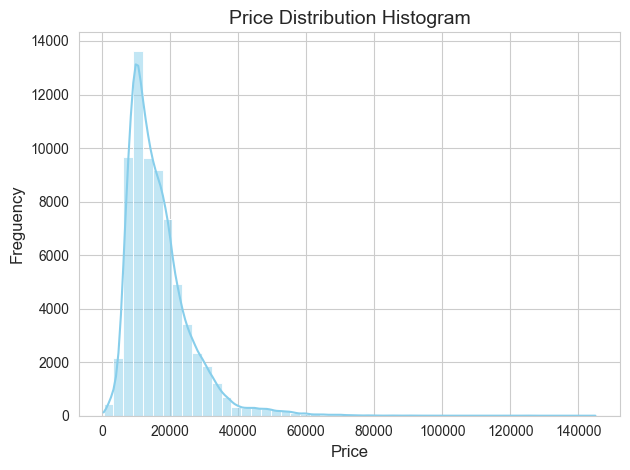

In [146]:
sns.set_style("whitegrid")
sns.histplot(df['price'], bins=50, kde=True, color='skyblue')
plt.title("Price Distribution Histogram", fontsize=14)
plt.xlabel("Price", fontsize=12)
plt.ylabel("Freguency", fontsize=12)
plt.tight_layout()
plt.show()

**Correlation heatmap (from EDA)**

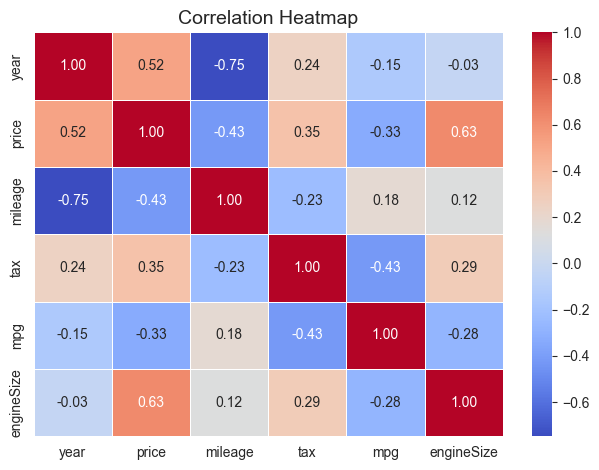

In [147]:
sns.set_style("white")
corr=df.corr(numeric_only=True)
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)
plt.title("Correlation Heatmap", fontsize=14)
plt.tight_layout()
plt.show()

**Predicted vs. Actual scatter plot (Regression)**

**Single Regression (Actual vs Predicted)**

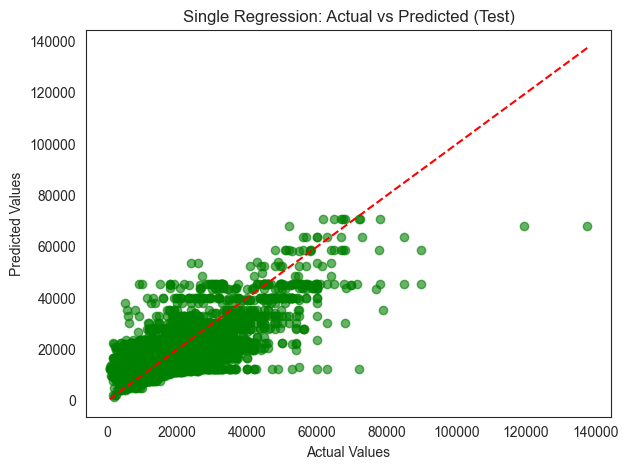

In [148]:
plt.scatter(y_test,y_pred_simple,alpha=0.6,color='green')
plt.plot([min(y_test),max(y_test)],[min(y_test),max(y_test)],color='red',linestyle='--')
plt.title("Single Regression: Actual vs Predicted (Test)")
plt.xlabel("Actual Values")
plt.ylabel("Predicted Values")
plt.tight_layout()
plt.show()

**Multiple Regression (Actual vs Predicted)**

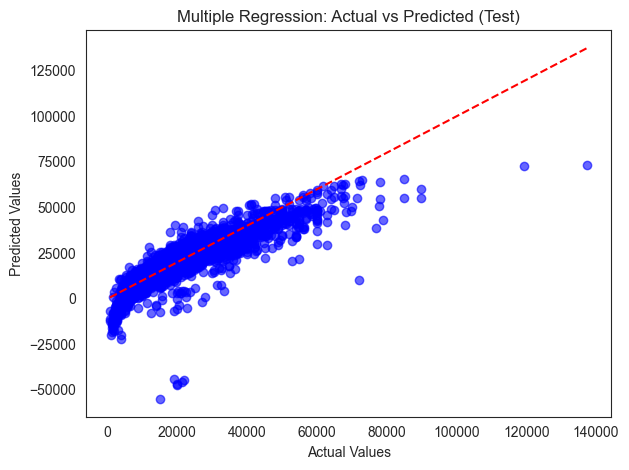

In [149]:
plt.scatter(y_test, y_pred_multi, alpha=0.6, color='blue')
plt.plot([min(y_test),max(y_test)],[min(y_test),max(y_test)],color='red',linestyle='--')
plt.title("Multiple Regression: Actual vs Predicted (Test)")
plt.xlabel("Actual Values")
plt.ylabel("Predicted Values")
plt.tight_layout()
plt.show()

**Confusion Matrix heatmap (Classification)**

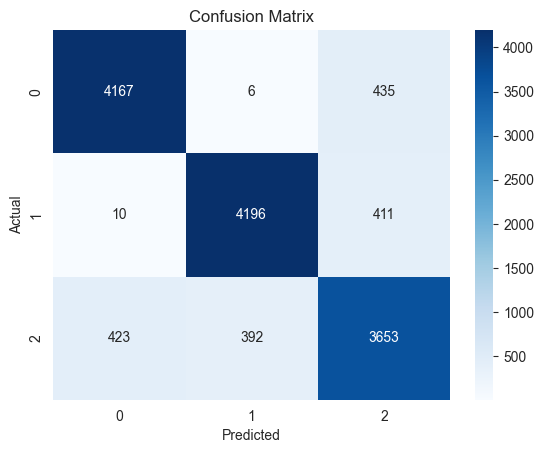

In [150]:

sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')

plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

**At least 2 additional meaningful plots of your choice — explain what it shows.**

**Plot 1: Price vs Mileage**

**This plot shows the relationship between mileage and price.
It helps determine whether cars with higher mileage tend to have lower prices. A scatter plot is used to visualize the relationship between mileage and price. It helps identify trends, correlations, and outliers between the two numerical variables. The plot may reveal a negative correlation, where higher mileage is associated with lower prices**

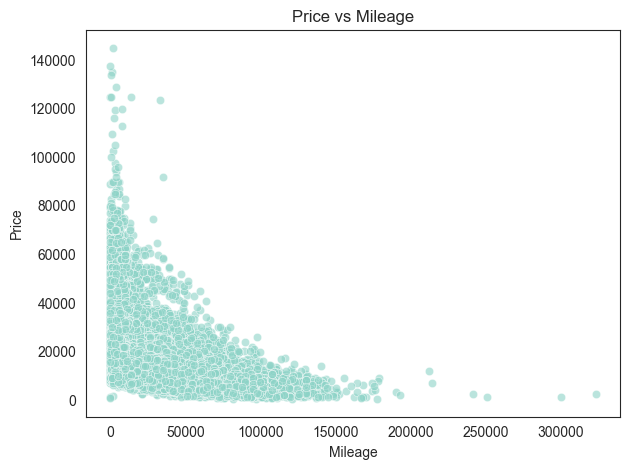

In [151]:
sns.scatterplot(x=df['mileage'], y=df['price'], alpha=0.6)
plt.title("Price vs Mileage")
plt.xlabel("Mileage")
plt.ylabel("Price")
plt.tight_layout()
plt.show()

**Plot 2: Price by Fuel Type**

**This plot compares the distribution of prices across different fuel types, helping identify which fuel types are associated with higher or lower prices. A box plot is used to visualize the distribution of prices across different fuel types, including median, variability, and outliers**

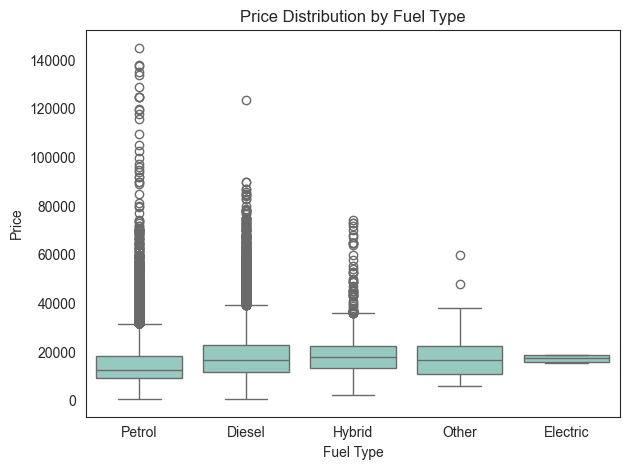

In [152]:
sns.boxplot(x=df['fuelType'], y=df['price'])
plt.title("Price Distribution by Fuel Type")
plt.xlabel("Fuel Type")
plt.ylabel("Price")
plt.tight_layout()
plt.show()